# Certified Counterfactual Generation on MNIST (Latent Space)

This notebook demonstrates the **CertCFAtlas** API operating in the **latent space** of a convolutional VAE.

**Key idea**: Instead of building certified polytopes in the full 784D input space, we:
1. **Encode** training samples into a compact 3D latent space using a trained VAE (using $\mu$ as the representation)
2. **Build the atlas** in latent space using a composite model: `decoder → classifier`
3. **Find counterfactuals** in 3D latent space, then **decode** back to pixel space for visualization

This approach offers several advantages:
- **Faster QP solves** (3D vs 784D)
- **Smoother interpolations** through the learned data manifold
- **Semantic counterfactuals** that change high-level structure rather than individual pixels

In [4]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import TensorDataset

import sys
sys.path.insert(0, '../src')
from models.classifiers import MNISTClassifier
from models.ae_channels import ConvAutoencoder
from certcf import CertCFAtlas

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 2 – Load Data & Models

We load the MNIST test set, the pre-trained CNN classifier, and the pre-trained convolutional VAE. We then:
1. Create a **composite model** (`decoder → classifier`) that maps flat 3D latent vectors to class logits
2. **Encode** all samples to the 3D latent space (using the encoder's $\mu$ output)

In [6]:
test_transform = transforms.Compose([
    transforms.ToTensor(),
])
full_test = datasets.MNIST(root='../data', train=False, download=True, transform=test_transform)

# Select a balanced subset (N_PER_CLASS samples per digit)
N_PER_CLASS = 100
targets = full_test.targets.numpy()

indices = []
for c in range(10):
    class_idx = np.where(targets == c)[0][:N_PER_CLASS]
    indices.extend(class_idx)

# Materialize transformed images into a TensorDataset
images = torch.stack([full_test[i][0] for i in indices])
labels = torch.tensor([full_test[i][1] for i in indices])

print(f'Dataset: {len(images)} samples ({N_PER_CLASS} per class), shape: {images.shape}')

# Load pre-trained CNN classifier from Lightning checkpoint
from training.lit_classifier import LitClassifier
lit_cls = LitClassifier.load_from_checkpoint(
    '../checkpoints/classifier/MNIST-Classifier-032-0.0144.ckpt',
    model=MNISTClassifier(num_classes=10)
)
model = lit_cls.model.to(device).eval()

# Load pre-trained MNIST VAE from Lightning checkpoint
from training.lit_autoencoder import LitAutoencoder
lit_ae = LitAutoencoder.load_from_checkpoint(
    '../checkpoints/autoencoder/last-v11.ckpt',
    model=ConvAutoencoder(latent_dim=3)
)
autoencoder = lit_ae.model.to(device).eval()

# Verify classifier accuracy
with torch.no_grad():
    preds = model(images.to(device)).argmax(dim=1).cpu()
    acc = (preds == labels).float().mean()
print(f'Classifier accuracy on subset: {acc*100:.1f}%')

# --- Composite model: decoder → classifier ---
class DecoderClassifier(nn.Module):
    """Maps flat latent vectors (3D) → class logits (10D) via decoder then classifier."""
    def __init__(self, decoder, classifier):
        super().__init__()
        self.decoder = decoder
        self.classifier = classifier

    def forward(self, z):
        x_reconstructed = self.decoder(z)              # (batch, 1, 28, 28)
        return self.classifier(x_reconstructed)        # (batch, 10)

composite_model = DecoderClassifier(autoencoder.decoder, model).to(device)
composite_model.eval()

# --- Encode all data to latent space (use mu as representation) ---
with torch.no_grad():
    mu, logvar = autoencoder.encoder(images.to(device))
    latent_vectors = mu.cpu()  # (1000, 3)

LATENT_DIM = latent_vectors.shape[1]
print(f'Latent space dimension: {LATENT_DIM}')

# Verify composite model accuracy (encode → decode → classify)
with torch.no_grad():
    composite_preds = composite_model(latent_vectors.to(device)).argmax(dim=1).cpu()
    composite_acc = (composite_preds == labels).float().mean()
print(f'Composite model accuracy (encode→decode→classify): {composite_acc*100:.1f}%')

# Create latent dataset for atlas
latent_dataset = TensorDataset(latent_vectors, labels)

# Helper: decode flat latent vector to displayable image
def decode_to_image(z_flat):
    """Decode a flat latent vector (3D) to a 28x28 image."""
    with torch.no_grad():
        z = torch.tensor(z_flat, dtype=torch.float32).unsqueeze(0).to(device)
        img = autoencoder.decoder(z).cpu().numpy()[0, 0]  # (28, 28)
    return np.clip(img, 0, 1)

Dataset: 1000 samples (100 per class), shape: torch.Size([1000, 1, 28, 28])
Classifier accuracy on subset: 99.4%
Latent space dimension: 3
Composite model accuracy (encode→decode→classify): 95.9%


## 3 – Build Certified Atlas in Latent Space

The atlas is built using the **composite model** (`decoder → classifier`) with 3D latent vectors as input. LiRPA computes certified linear bounds in the latent space:

$$A_i \mathbf{z} + \mathbf{b}_i \leq f_t(\text{decoder}(\mathbf{z})) - f_j(\text{decoder}(\mathbf{z})) \quad \forall j \neq t$$

Since we're in 3D instead of 784D, QP solves are dramatically faster.

In [ ]:
# Build atlas in latent space using composite model (decoder → classifier)
# cnn=False because input is flat 3D latent vectors
atlas = CertCFAtlas(composite_model, latent_dataset, device, cnn=False, solver_maxiter=3000)

atlas.build(
    eps=0.1,
    norm=2,
    batch_size=4,
    verbose=True,
)

Building certified atlas (eps=0.1, L2 norm)...
  Computing LiRPA bounds...


Computing bounds:  10%|█         | 1/10 [00:16<02:25, 16.22s/it]

## 3.1 – Preimage Approximation Quality

The certified atlas approximates each class preimage as a **union of convex polytopes**:

$$\mathcal{R}_c \;=\; \bigcup_{i=1}^{N_c} \bigl\{\, \mathbf{z} \;\big|\; A_i \mathbf{z} + \mathbf{b}_i \geq \mathbf{0}\bigr\} \;\cap\; \mathcal{B}_p(\mathbf{z}_i, \varepsilon)$$

If the LiRPA bounds are too loose, the halfspace constraints become infeasible or leave only a sliver of volume — the polytope **collapses** to its center point, and the method degenerates to nearest-neighbor comparison against training data.

We assess quality through four complementary metrics:

| Metric | What it measures | Collapse signal |
|--------|-----------------|-----------------|
| **Feasibility** | Can the center even satisfy all constraints? | Infeasible = no polytope at all |
| **Center margins** | How far is the center from each halfspace boundary? | All margins $\approx 0$ = paper-thin |
| **Chebyshev radius** | Radius of largest inscribed $L_2$-ball | $r \approx 0$ vs $r = \varepsilon$ (unconstrained) |
| **Volume ratio** | $\mathrm{vol}(\text{polytope}) \;/\; \mathrm{vol}(\text{box})$ via Monte Carlo | Ratio $\approx 0$ = collapsed |

In [4]:
import pandas as pd

# ── Compute all polytope-level metrics ──────────────────────────────────────
d = atlas.bounds[0]['X'].shape[1]  # latent dimension
N_MC = 5000                         # Monte Carlo samples for volume ratio

polytope_records = []
for label in range(10):
    bd = atlas.bounds[label]
    n = len(bd['X'])
    for i in range(n):
        center = bd['X'][i]
        lA_i = bd['lA'][i]       # (k-1, d)
        lbias_i = bd['lbias'][i] # (k-1,)

        # Center margins: m_j = lA_j @ center + lbias_j
        margins = lA_i @ center + lbias_i
        min_margin = margins.min()
        mean_margin = margins.mean()
        feasible = min_margin >= -1e-6

        # Chebyshev radius (largest inscribed L2-ball at center)
        cheb_r = 0.0
        if feasible:
            row_norms = np.linalg.norm(lA_i, axis=1, ord=2)
            row_norms = np.maximum(row_norms, 1e-12)
            cheb_r = np.min(margins / row_norms)
            cheb_r = min(cheb_r, atlas.eps)

        # Volume ratio via Monte Carlo: sample uniformly in box, check halfspace feasibility
        vol_ratio = 0.0
        if feasible:
            samples = center + atlas.eps * (2 * np.random.rand(N_MC, d) - 1)
            halfspace_ok = np.all(samples @ lA_i.T + lbias_i >= 0, axis=1)
            vol_ratio = halfspace_ok.mean()

        polytope_records.append({
            'class': label,
            'idx': i,
            'feasible': feasible,
            'min_margin': min_margin,
            'mean_margin': mean_margin,
            'chebyshev_r': cheb_r,
            'cheb_r_ratio': cheb_r / atlas.eps if atlas.eps > 0 else 0,
            'volume_ratio': vol_ratio,
        })

poly_df = pd.DataFrame(polytope_records)
feasible_df = poly_df[poly_df['feasible']]

# ── Summary table ───────────────────────────────────────────────────────────
print(f'Atlas: eps={atlas.eps}, L{atlas.norm} norm, {d}D latent space')
print(f'Total polytopes: {len(poly_df)}, feasible: {feasible_df.shape[0]} '
      f'({100*feasible_df.shape[0]/len(poly_df):.1f}%)\n')

summary_rows = []
for label in range(10):
    cls = feasible_df[feasible_df['class'] == label]
    total_cls = poly_df[poly_df['class'] == label]
    summary_rows.append({
        'Digit': label,
        'Feasible': f'{len(cls)}/{len(total_cls)}',
        'Min margin (med)': f'{cls["min_margin"].median():.4f}' if len(cls) > 0 else '-',
        'Cheb. radius (med)': f'{cls["chebyshev_r"].median():.4f}' if len(cls) > 0 else '-',
        'Cheb. r/eps (med)': f'{cls["cheb_r_ratio"].median():.2%}' if len(cls) > 0 else '-',
        'Vol. ratio (med)': f'{cls["volume_ratio"].median():.2%}' if len(cls) > 0 else '-',
    })
summary = pd.DataFrame(summary_rows)
print(summary.to_string(index=False))

# Overall
print(f'\n{"Overall":>8}: Cheb. r/eps median={feasible_df["cheb_r_ratio"].median():.2%}, '
      f'Vol. ratio median={feasible_df["volume_ratio"].median():.2%}')

Atlas: eps=0.1, L2 norm, 32D latent space
Total polytopes: 1000, feasible: 0 (0.0%)

 Digit Feasible Min margin (med) Cheb. radius (med) Cheb. r/eps (med) Vol. ratio (med)
     0    0/100                -                  -                 -                -
     1    0/100                -                  -                 -                -
     2    0/100                -                  -                 -                -
     3    0/100                -                  -                 -                -
     4    0/100                -                  -                 -                -
     5    0/100                -                  -                 -                -
     6    0/100                -                  -                 -                -
     7    0/100                -                  -                 -                -
     8    0/100                -                  -                 -                -
     9    0/100                -             

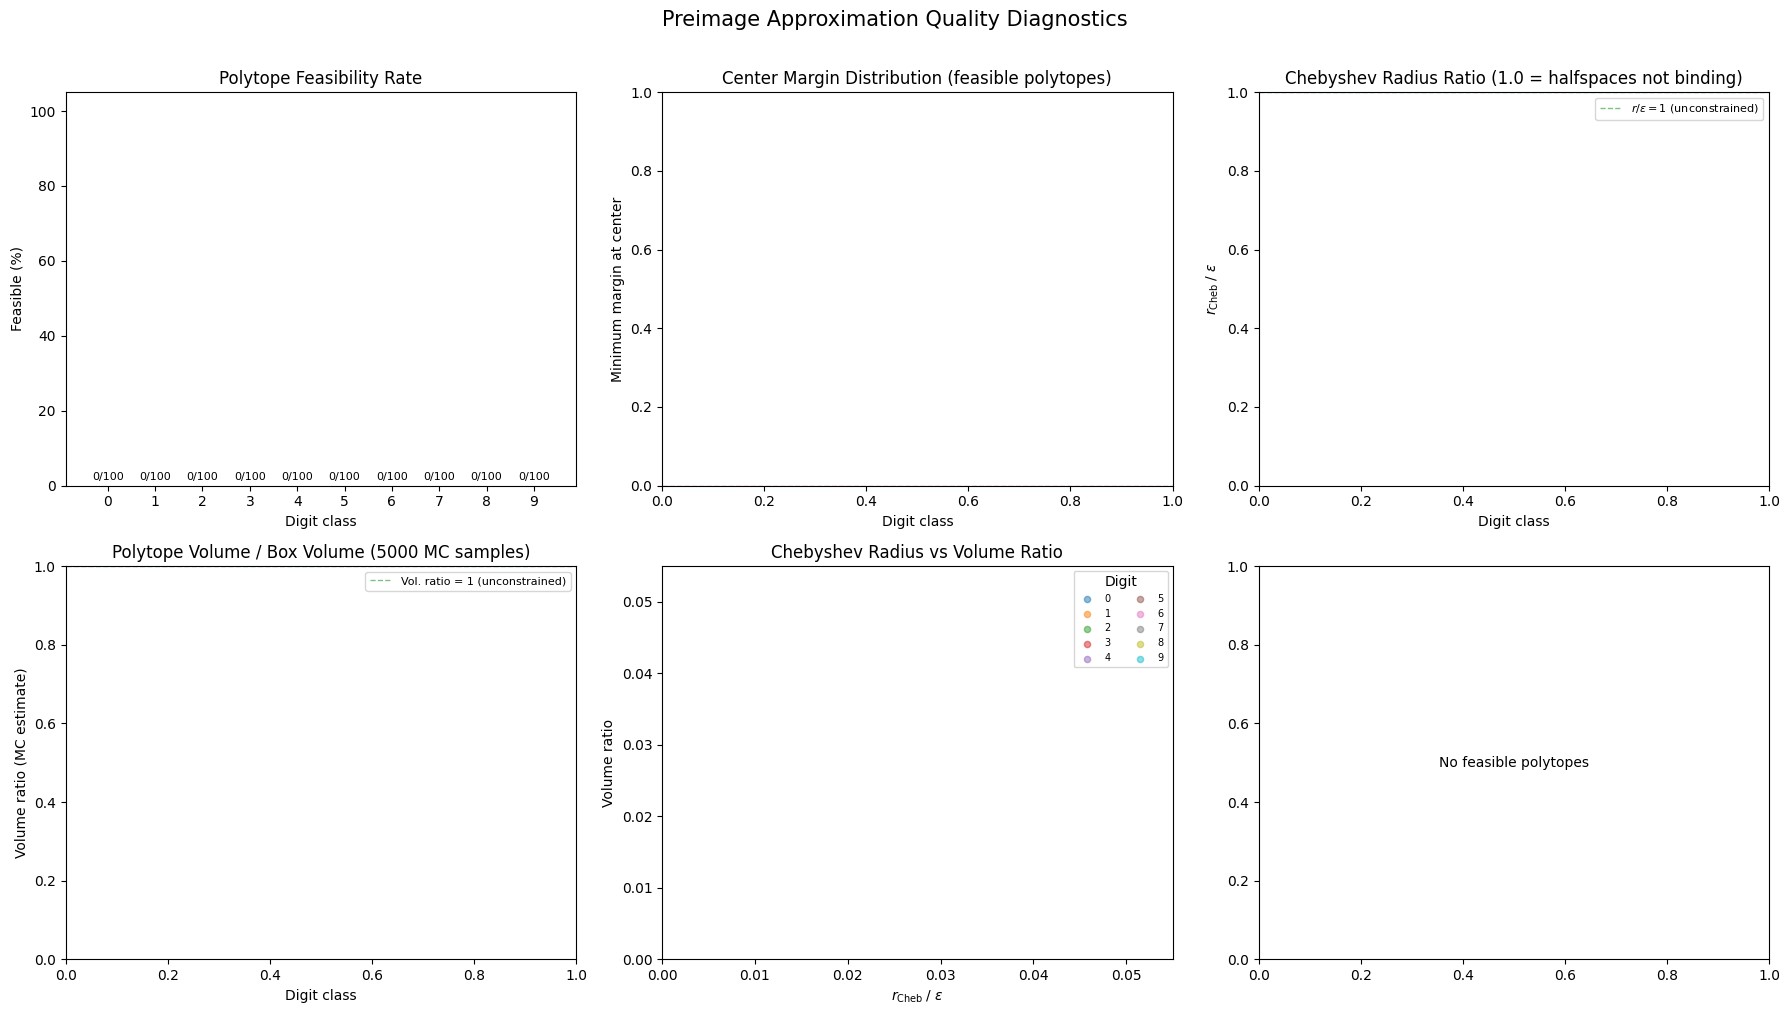

In [5]:
cmap = plt.colormaps.get_cmap('tab10')

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# ── (0,0) Feasibility bar chart ────────────────────────────────────────────
ax = axes[0, 0]
feas_counts = poly_df.groupby('class')['feasible'].agg(['sum', 'count'])
bars = ax.bar(range(10), feas_counts['sum'] / feas_counts['count'] * 100,
              color=[cmap(i) for i in range(10)], edgecolor='white')
ax.set_xlabel('Digit class')
ax.set_ylabel('Feasible (%)')
ax.set_title('Polytope Feasibility Rate')
ax.set_ylim(0, 105)
ax.set_xticks(range(10))
for bar, row in zip(bars, feas_counts.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{int(row.sum)}/{int(row.count)}', ha='center', va='bottom', fontsize=8)

# ── (0,1) Center margin distribution (violin) ─────────────────────────────
ax = axes[0, 1]
import seaborn as sns
sns.violinplot(ax=ax, x='class', y='min_margin', data=feasible_df,
               hue='class', palette='tab10', legend=False, inner='quart', cut=0)
ax.axhline(0, color='red', linestyle='--', alpha=0.5, linewidth=1)
ax.set_xlabel('Digit class')
ax.set_ylabel('Minimum margin at center')
ax.set_title('Center Margin Distribution (feasible polytopes)')

# ── (0,2) Chebyshev radius / eps ratio (box) ──────────────────────────────
ax = axes[0, 2]
sns.boxplot(ax=ax, x='class', y='cheb_r_ratio', data=feasible_df,
            hue='class', palette='tab10', legend=False)
ax.axhline(1.0, color='green', linestyle='--', alpha=0.5, linewidth=1,
           label=r'$r/\varepsilon = 1$ (unconstrained)')
ax.set_xlabel('Digit class')
ax.set_ylabel(r'$r_{\mathrm{Cheb}} \;/\; \varepsilon$')
ax.set_title('Chebyshev Radius Ratio (1.0 = halfspaces not binding)')
ax.set_ylim(bottom=0)
ax.legend(fontsize=8)

# ── (1,0) Volume ratio distribution (box) ─────────────────────────────────
ax = axes[1, 0]
sns.boxplot(ax=ax, x='class', y='volume_ratio', data=feasible_df,
            hue='class', palette='tab10', legend=False)
ax.axhline(1.0, color='green', linestyle='--', alpha=0.5, linewidth=1,
           label='Vol. ratio = 1 (unconstrained)')
ax.set_xlabel('Digit class')
ax.set_ylabel('Volume ratio (MC estimate)')
ax.set_title(f'Polytope Volume / Box Volume ({N_MC} MC samples)')
ax.set_ylim(bottom=0)
ax.legend(fontsize=8)

# ── (1,1) Chebyshev radius vs volume ratio scatter ────────────────────────
ax = axes[1, 1]
for label in range(10):
    cls = feasible_df[feasible_df['class'] == label]
    ax.scatter(cls['cheb_r_ratio'], cls['volume_ratio'],
               c=[cmap(label)], alpha=0.5, s=20, label=str(label))
ax.set_xlabel(r'$r_{\mathrm{Cheb}} \;/\; \varepsilon$')
ax.set_ylabel('Volume ratio')
ax.set_title('Chebyshev Radius vs Volume Ratio')
ax.legend(fontsize=7, ncol=2, title='Digit')
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

# ── (1,2) Per-dimension feasible extent (bar chart) ──────────────────────
ax = axes[1, 2]
d = LATENT_DIM
all_extents = np.zeros(d)
n_counted = 0
for label in range(10):
    bd = atlas.bounds[label]
    for i in range(len(bd['X'])):
        margins = bd['lA'][i] @ bd['X'][i] + bd['lbias'][i]
        if margins.min() < -1e-6:
            continue
        center = bd['X'][i]
        lA_i = bd['lA'][i]
        lbias_i = bd['lbias'][i]
        dim_extent = np.zeros(d)
        for dim in range(d):
            test_points = np.tile(center, (100, 1))
            offsets = np.linspace(-atlas.eps, atlas.eps, 100)
            test_points[:, dim] = center[dim] + offsets
            feas_mask = np.all(test_points @ lA_i.T + lbias_i >= 0, axis=1)
            if feas_mask.any():
                feasible_offsets = offsets[feas_mask]
                dim_extent[dim] = feasible_offsets.max() - feasible_offsets.min()
            else:
                dim_extent[dim] = 0
        all_extents += dim_extent / (2 * atlas.eps)
        n_counted += 1

if n_counted > 0:
    avg_extent = all_extents / n_counted
    colors = plt.cm.RdYlGn(avg_extent)
    ax.bar(range(d), avg_extent, color=colors, edgecolor='none')
    ax.axhline(1.0, color='green', linestyle='--', alpha=0.3, linewidth=1)
    ax.set_xlabel('Latent dimension')
    ax.set_ylabel('Avg. feasible extent (0-1)')
    ax.set_title(f'Per-Dimension Feasible Extent ({d}D)\n(1.0 = fully free, 0.0 = locked)')
    ax.set_ylim(0, 1.05)
else:
    ax.text(0.5, 0.5, 'No feasible polytopes', ha='center', va='center', transform=ax.transAxes)

plt.suptitle('Preimage Approximation Quality Diagnostics', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

/tmp/ipykernel_138960/1922999985.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


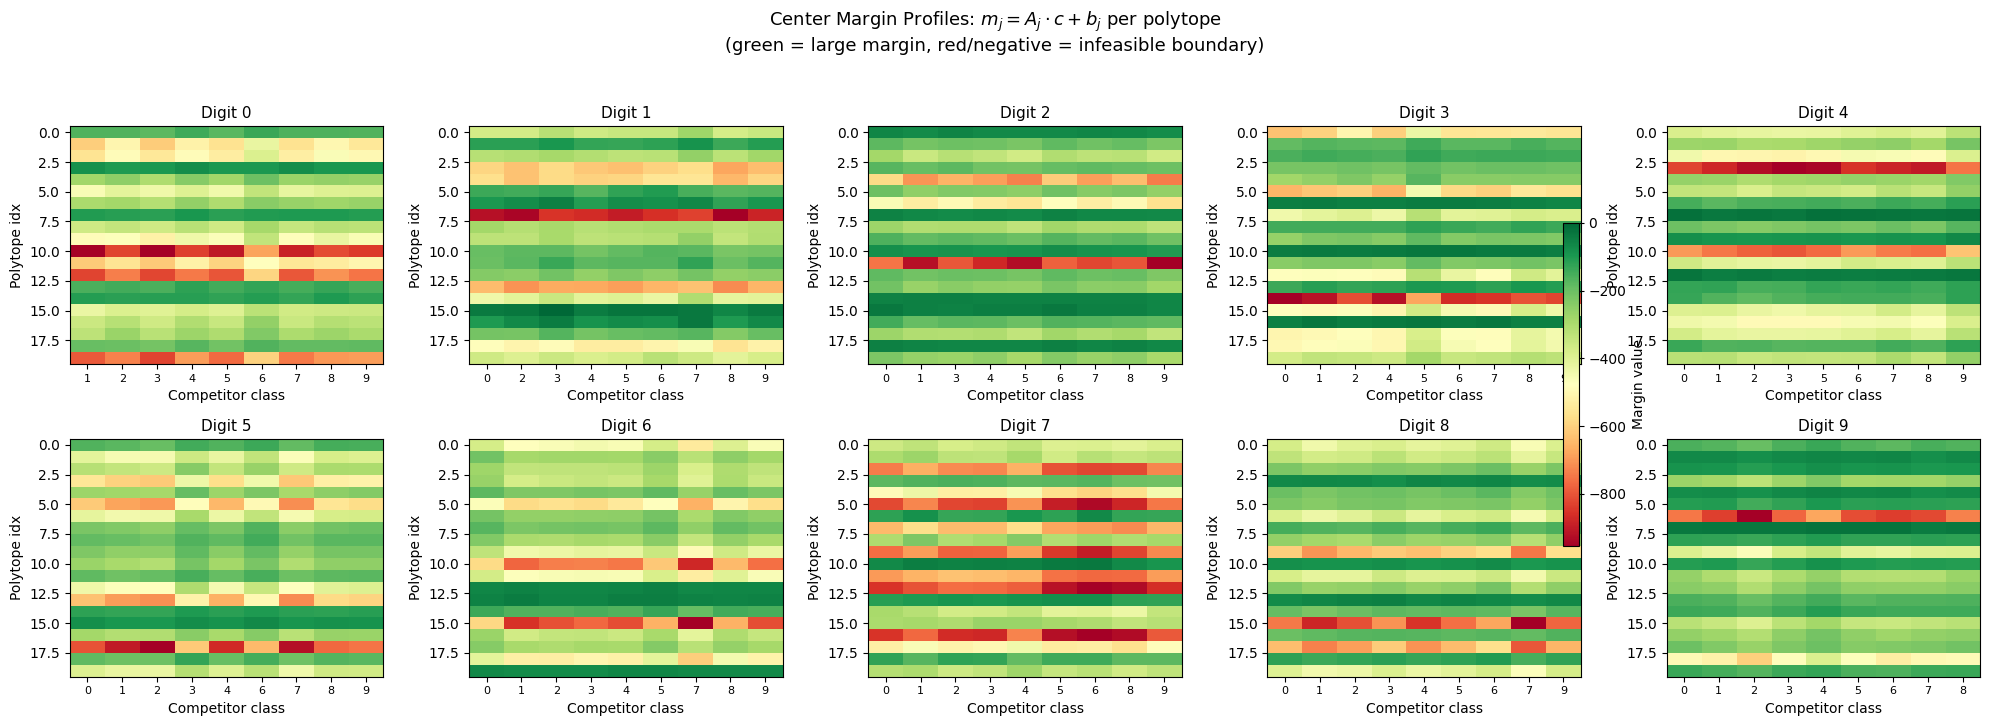

In [6]:
# ── Margin profile heatmap: all k-1 margins for sample polytopes ───────────
# Shows which class boundaries are tight (near 0) vs loose (large margin)
# Each row = one polytope, each column = one competitor class margin

fig, axes = plt.subplots(2, 5, figsize=(20, 7))
axes = axes.flatten()

for label in range(10):
    ax = axes[label]
    bd = atlas.bounds[label]
    n_show = min(20, len(bd['X']))

    margin_matrix = np.zeros((n_show, bd['lA'].shape[1]))
    for i in range(n_show):
        margin_matrix[i] = bd['lA'][i] @ bd['X'][i] + bd['lbias'][i]

    # Competitor class labels (all classes except current)
    competitor_labels = [str(c) for c in range(10) if c != label]

    im = ax.imshow(margin_matrix, aspect='auto', cmap='RdYlGn', vmin=margin_matrix.min(),
                   vmax=max(margin_matrix.max(), 1e-6))
    ax.set_xlabel('Competitor class')
    ax.set_ylabel('Polytope idx')
    ax.set_title(f'Digit {label}', fontsize=11)
    ax.set_xticks(range(len(competitor_labels)))
    ax.set_xticklabels(competitor_labels, fontsize=8)

plt.suptitle('Center Margin Profiles: $m_j = A_j \\cdot c + b_j$ per polytope\n'
             '(green = large margin, red/negative = infeasible boundary)',
             fontsize=13, y=1.03)
fig.colorbar(im, ax=axes, shrink=0.6, label='Margin value')
plt.tight_layout()
plt.show()

## 4 – Visualize Dataset Samples (Decoded from Latent Space)

We decode latent vectors back to image space to visualize the training samples used by the atlas.

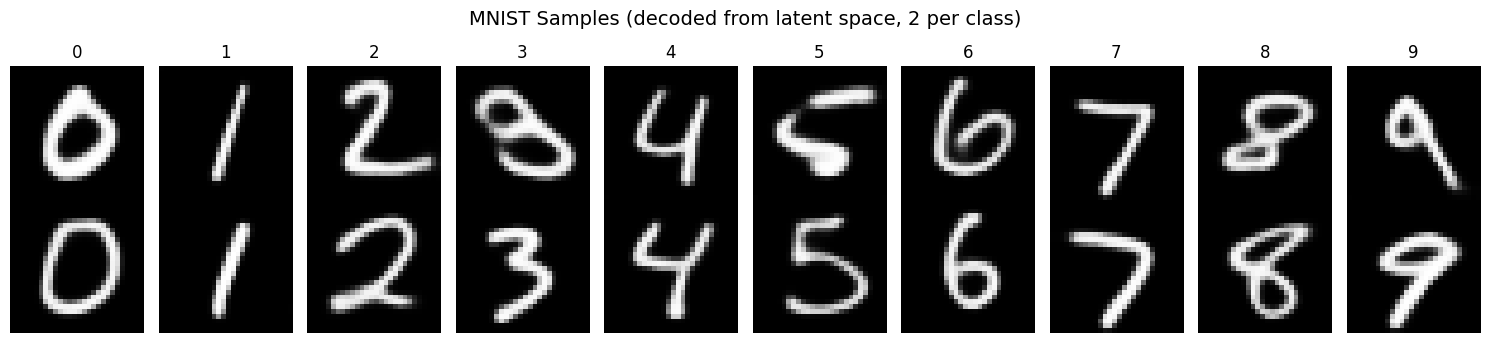

In [7]:
fig, axes = plt.subplots(2, 10, figsize=(15, 3.5))
for digit in range(10):
    Z_digit = atlas.bounds[digit]['X']
    for row in range(2):
        ax = axes[row, digit]
        ax.imshow(decode_to_image(Z_digit[row]), cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
        if row == 0:
            ax.set_title(str(digit), fontsize=12)

fig.suptitle('MNIST Samples (decoded from latent space, 2 per class)', fontsize=14)
plt.tight_layout()
plt.show()

In [8]:
# Visualize latent vectors (flat 32D) alongside original images and reconstructions
fig, axes = plt.subplots(3, 10, figsize=(15, 5))

for digit in range(10):
    digit_mask = labels == digit
    digit_images = images[digit_mask]
    digit_latents = latent_vectors[digit_mask]

    # Row 0: original image
    ax = axes[0, digit]
    ax.imshow(digit_images[0, 0].numpy(), cmap='gray', vmin=0, vmax=1)
    ax.axis('off')
    ax.set_title(str(digit), fontsize=12)

    # Row 1: latent vector as 1D bar chart
    ax = axes[1, digit]
    z = digit_latents[0].numpy()
    ax.bar(range(len(z)), z, color='steelblue', width=1.0)
    ax.set_xlim(-0.5, len(z) - 0.5)
    ax.set_xticks([])
    ax.set_yticks([])

    # Row 2: decoded reconstruction
    ax = axes[2, digit]
    ax.imshow(decode_to_image(digit_latents[0].numpy()), cmap='gray', vmin=0, vmax=1)
    ax.axis('off')

axes[0, 0].set_ylabel('Original', fontsize=10, rotation=0, labelpad=55, va='center')
axes[1, 0].set_ylabel(f'Latent ({LATENT_DIM}D)', fontsize=10, rotation=0, labelpad=55, va='center')
axes[2, 0].set_ylabel('Decoded', fontsize=10, rotation=0, labelpad=55, va='center')

fig.suptitle(f'Latent Space Representations ({LATENT_DIM}D flat vectors)', fontsize=14)
plt.tight_layout()
plt.show()

## 5 – Generate Counterfactuals in Latent Space

For selected query digits, we find the closest certified counterfactual in the **latent space**. The query point is encoded to 3D, the counterfactual search operates entirely in latent space, and results are decoded back to images for visualization.

Given a query latent vector $\mathbf{z}_0 = \mu_{\text{encoder}}(\mathbf{x}_0)$, we solve:

$$\min_{\mathbf{z}} \;\|\mathbf{z} - \mathbf{z}_0\|_2^2 \qquad \text{s.t.} \quad A_i \mathbf{z} + \mathbf{b}_i \geq \mathbf{0}, \quad \|\mathbf{z} - \mathbf{c}_i\|_2 \leq \varepsilon$$

and return the decoded image $\text{decoder}(\mathbf{z}_{cf})$ as the counterfactual explanation.

In [9]:
source_class = 8
n_queries = 3
# Query points are latent vectors from the atlas
query_points = atlas.bounds[source_class]['X'][:n_queries]

print(f'Generating counterfactuals for {n_queries} queries from digit {source_class}')
print(f'(operating in {query_points.shape[1]}D latent space)\n')

all_results = {}
for target_class in range(10):
    if target_class == source_class:
        continue

    results = []
    for i, z0 in enumerate(query_points):
        result = atlas.find_counterfactual(z0, target_class, method='bvh')
        results.append(result)

    all_results[target_class] = results
    n_ok = sum(r.success for r in results)
    avg_dist = np.mean([r.distance for r in results if r.success]) if n_ok > 0 else float('inf')
    avg_qp = np.mean([r.n_qp_solved for r in results])
    print(f'  -> Digit {target_class}: {n_ok}/{n_queries} success, '
          f'avg latent dist={avg_dist:.4f}, avg QPs={avg_qp:.1f}')

Generating counterfactuals for 3 queries from digit 8
(operating in 32D latent space)

  -> Digit 0: 0/3 success, avg latent dist=inf, avg QPs=100.0
  -> Digit 1: 0/3 success, avg latent dist=inf, avg QPs=100.0
  -> Digit 2: 0/3 success, avg latent dist=inf, avg QPs=100.0
  -> Digit 3: 0/3 success, avg latent dist=inf, avg QPs=100.0
  -> Digit 4: 0/3 success, avg latent dist=inf, avg QPs=100.0
  -> Digit 5: 0/3 success, avg latent dist=inf, avg QPs=100.0
  -> Digit 6: 0/3 success, avg latent dist=inf, avg QPs=100.0
  -> Digit 7: 0/3 success, avg latent dist=inf, avg QPs=100.0
  -> Digit 9: 0/3 success, avg latent dist=inf, avg QPs=100.0


## 6 – Verify Counterfactuals

All counterfactuals lie inside certified polytopes, so they are **guaranteed** to be classified correctly.

In [10]:
print('Verifying counterfactual validity:\n')

all_valid = True
for target_class, results in all_results.items():
    for i, result in enumerate(results):
        if not result.success:
            all_valid = False
            continue
        verification = atlas.verify_counterfactual(result.x_cf, target_class)
        if not verification['valid']:
            print(f'  INVALID: query {i} -> digit {target_class}, '
                  f'pred={verification["predicted"]}')
            all_valid = False

print(f'All counterfactuals valid: {all_valid}')

Verifying counterfactual validity:

All counterfactuals valid: False


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

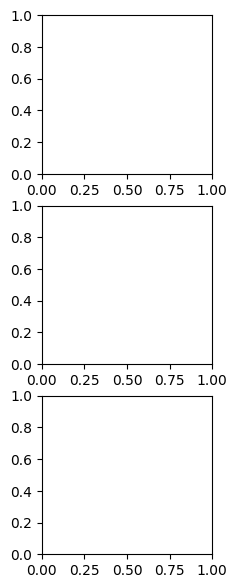

In [15]:
# Counterfactuals sorted by distance: latent space vs image space
# For each query, collect all successful counterfactuals and rank them

query_idx = 0
z_orig = query_points[query_idx]
img_orig = decode_to_image(z_orig)

# Collect distances in both spaces
cf_data = []
for target_class, results in all_results.items():
    result = results[query_idx]
    if not result.success:
        continue
    img_cf = decode_to_image(result.x_cf)
    latent_dist = np.linalg.norm(result.x_cf - z_orig)
    image_dist = np.linalg.norm(img_cf - img_orig)
    cf_data.append({
        'target': target_class,
        'latent_dist': latent_dist,
        'image_dist': image_dist,
        'z_cf': result.x_cf,
        'img_cf': img_cf,
    })

# Sort by latent distance and by image distance
sorted_latent = sorted(cf_data, key=lambda d: d['latent_dist'])
sorted_image = sorted(cf_data, key=lambda d: d['image_dist'])

n_cf = len(cf_data)
fig, axes = plt.subplots(3, n_cf + 1, figsize=(2.2 * (n_cf + 1), 7))

# Column 0: original query
for row in range(3):
    ax = axes[row, 0]
    ax.imshow(img_orig, cmap='gray', vmin=0, vmax=1)
    ax.set_xticks([]); ax.set_yticks([])
    if row == 0:
        ax.set_title(f'Query\n(digit {source_class})', fontsize=10)

axes[0, 0].set_ylabel('Sorted by\nlatent L2', fontsize=10, rotation=0, labelpad=60, va='center')
axes[1, 0].set_ylabel('Sorted by\nimage L2', fontsize=10, rotation=0, labelpad=60, va='center')
axes[2, 0].set_ylabel('Image\ndifference', fontsize=10, rotation=0, labelpad=60, va='center')

# Row 0: sorted by latent distance
for col, d in enumerate(sorted_latent, 1):
    ax = axes[0, col]
    ax.imshow(d['img_cf'], cmap='gray', vmin=0, vmax=1)
    ax.set_title(f"{d['target']}\nz={d['latent_dist']:.1f}", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])

# Row 1: sorted by image distance
for col, d in enumerate(sorted_image, 1):
    ax = axes[1, col]
    ax.imshow(d['img_cf'], cmap='gray', vmin=0, vmax=1)
    ax.set_title(f"{d['target']}\npx={d['image_dist']:.1f}", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])

# Row 2: image-space difference maps (sorted by image distance)
for col, d in enumerate(sorted_image, 1):
    ax = axes[2, col]
    diff = d['img_cf'] - img_orig
    vmax = max(abs(diff.min()), abs(diff.max()), 1e-8)
    ax.imshow(diff, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax.set_xticks([]); ax.set_yticks([])

fig.suptitle(f'Counterfactuals for digit {source_class} (query {query_idx}): '
             f'latent vs image space ranking', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Print ranking comparison
print(f'{"Rank":<5} {"Latent sort":>20} {"Image sort":>20}')
print('-' * 47)
for i in range(n_cf):
    lt = sorted_latent[i]
    im = sorted_image[i]
    print(f'{i+1:<5} digit {lt["target"]} (z={lt["latent_dist"]:.2f})'
          f'    digit {im["target"]} (px={im["image_dist"]:.2f})')

### 6.1 – Polytope Value-Add: Are Polytopes Better Than Nearest-Neighbor?

The critical question: do the certified polytopes provide counterfactuals that are **closer** than the nearest training point of the target class? If not, the preimage approximation has collapsed and the polytopes are useless.

We measure two key indicators:

| Metric | Formula | Interpretation |
|--------|---------|---------------|
| **NN distance ratio** | $d(\mathbf{z}_q, \mathbf{z}_{cf}) \;/\; d(\mathbf{z}_q, \text{NN}_{target})$ | $< 1$: polytope interior is closer than any training point |
| **CF displacement** | $d(\mathbf{z}_{cf}, \mathbf{c}_{polytope}) \;/\; \varepsilon$ | $\approx 0$: CF collapsed to center (= training point) |

In [12]:
# ── Compute value-add metrics for all counterfactuals ───────────────────────
# For each (query, target) pair, compare:
#   1. CF distance vs nearest-neighbor distance to target class training points
#   2. How far the CF moved away from the polytope center

value_add_rows = []
for target_class, results in all_results.items():
    # All training points of the target class
    target_centers = atlas.bounds[target_class]['X']  # (N_target, d)

    for qi in range(n_queries):
        result = results[qi]
        if not result.success:
            continue

        z_q = query_points[qi]
        z_cf = result.x_cf

        # NN distance: distance from query to nearest target training point
        dists_to_centers = np.linalg.norm(target_centers - z_q, axis=1)
        nn_dist = dists_to_centers.min()
        nn_idx = dists_to_centers.argmin()

        # CF distance
        cf_dist = result.distance

        # CF displacement from the polytope center it landed in
        # Find which polytope center is closest to the CF
        dists_cf_to_centers = np.linalg.norm(target_centers - z_cf, axis=1)
        closest_center_idx = dists_cf_to_centers.argmin()
        cf_displacement = dists_cf_to_centers[closest_center_idx]

        value_add_rows.append({
            'source': source_class,
            'target': target_class,
            'query_idx': qi,
            'cf_dist': cf_dist,
            'nn_dist': nn_dist,
            'nn_ratio': cf_dist / nn_dist if nn_dist > 0 else 1.0,
            'cf_displacement': cf_displacement,
            'cf_disp_ratio': cf_displacement / atlas.eps if atlas.eps > 0 else 0,
        })

va_df = pd.DataFrame(value_add_rows)

# ── Print summary ──────────────────────────────────────────────────────────
n_improved = (va_df['nn_ratio'] < 1.0 - 1e-6).sum()
n_equal = ((va_df['nn_ratio'] >= 1.0 - 1e-6) & (va_df['nn_ratio'] <= 1.0 + 1e-6)).sum()
n_total = len(va_df)

print(f'Polytope value-add analysis ({n_total} counterfactuals):\n')
print(f'  CF closer than NN:      {n_improved}/{n_total} ({100*n_improved/n_total:.1f}%)')
print(f'  CF = NN (collapsed):    {n_equal}/{n_total} ({100*n_equal/n_total:.1f}%)')
print(f'  NN ratio (median):      {va_df["nn_ratio"].median():.4f}')
print(f'  CF displacement/eps:    {va_df["cf_disp_ratio"].median():.4f} (median)')
print()

# ── Per-target breakdown ───────────────────────────────────────────────────
print(f'{"Target":>7} {"Improved":>10} {"NN ratio":>12} {"Disp/eps":>12}')
print('-' * 45)
for t in sorted(va_df['target'].unique()):
    sub = va_df[va_df['target'] == t]
    n_imp = (sub['nn_ratio'] < 1.0 - 1e-6).sum()
    print(f'{t:>7d} {n_imp:>5d}/{len(sub):<4d} {sub["nn_ratio"].median():>12.4f} '
          f'{sub["cf_disp_ratio"].median():>12.4f}')

KeyError: 'nn_ratio'

INFO     19:21:09     [category.py:224] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO     19:21:09     [category.py:224] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO     19:21:09     [category.py:224] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO     19:21:09     [category.py:224] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


/home/gabrielepintus/.local/lib/python3.13/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/home/gabrielepintus/.local/lib/python3.13/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/home/gabrielepintus/.local/lib/python3.13/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/home/gabrielepintus/.local/lib/python3.13/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


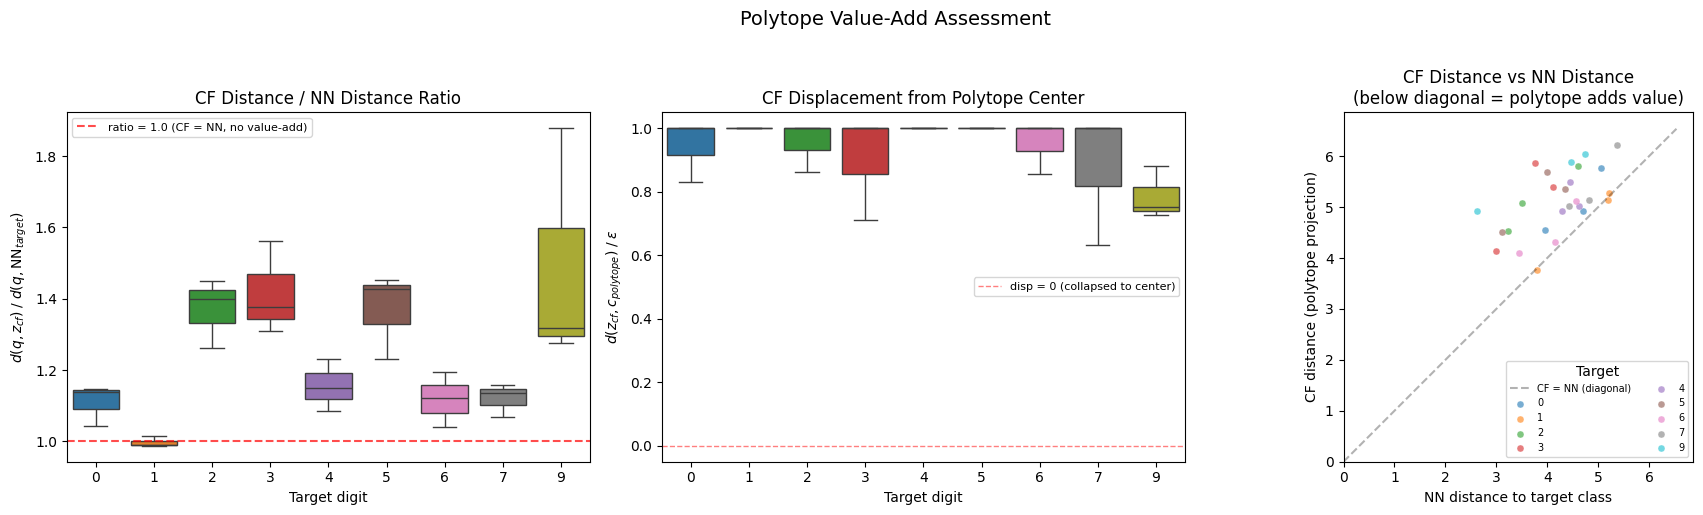

In [ ]:
# ── Visualize value-add metrics ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── (0) NN ratio distribution by target class ─────────────────────────────
ax = axes[0]
sns.boxplot(ax=ax, x='target', y='nn_ratio', data=va_df,
            hue='target', palette='tab10', legend=False)
ax.axhline(1.0, color='red', linestyle='--', linewidth=1.5, alpha=0.7,
           label='ratio = 1.0 (CF = NN, no value-add)')
ax.set_xlabel('Target digit')
ax.set_ylabel(r'$d(q, z_{cf}) \;/\; d(q, \mathrm{NN}_{target})$')
ax.set_title('CF Distance / NN Distance Ratio')
ax.legend(fontsize=8)

# ── (1) CF displacement / eps by target class ─────────────────────────────
ax = axes[1]
sns.boxplot(ax=ax, x='target', y='cf_disp_ratio', data=va_df,
            hue='target', palette='tab10', legend=False)
ax.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5,
           label='disp = 0 (collapsed to center)')
ax.set_xlabel('Target digit')
ax.set_ylabel(r'$d(z_{cf}, c_{polytope}) \;/\; \varepsilon$')
ax.set_title('CF Displacement from Polytope Center')
ax.set_ylim(bottom=-0.05)
ax.legend(fontsize=8)

# ── (2) CF distance vs NN distance scatter ────────────────────────────────
ax = axes[2]
max_val = max(va_df['cf_dist'].max(), va_df['nn_dist'].max()) * 1.05
ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, label='CF = NN (diagonal)')
for t in sorted(va_df['target'].unique()):
    sub = va_df[va_df['target'] == t]
    ax.scatter(sub['nn_dist'], sub['cf_dist'], c=[cmap(t)], alpha=0.6,
               s=25, label=str(t), edgecolors='white', linewidth=0.3)
ax.set_xlabel('NN distance to target class')
ax.set_ylabel('CF distance (polytope projection)')
ax.set_title('CF Distance vs NN Distance\n(below diagonal = polytope adds value)')
ax.legend(fontsize=7, ncol=2, title='Target')
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.set_aspect('equal')

plt.suptitle('Polytope Value-Add Assessment', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 7 – Counterfactual Interpolation Paths (in Latent Space)

For each target class, we interpolate in the **latent space**: $\mathbf{z}(\alpha) = (1-\alpha)\,\mathbf{z}_0 + \alpha\,\mathbf{z}_{cf}$ and decode each interpolant to image space. The prediction at each step is computed by the full pipeline (decode then classify).

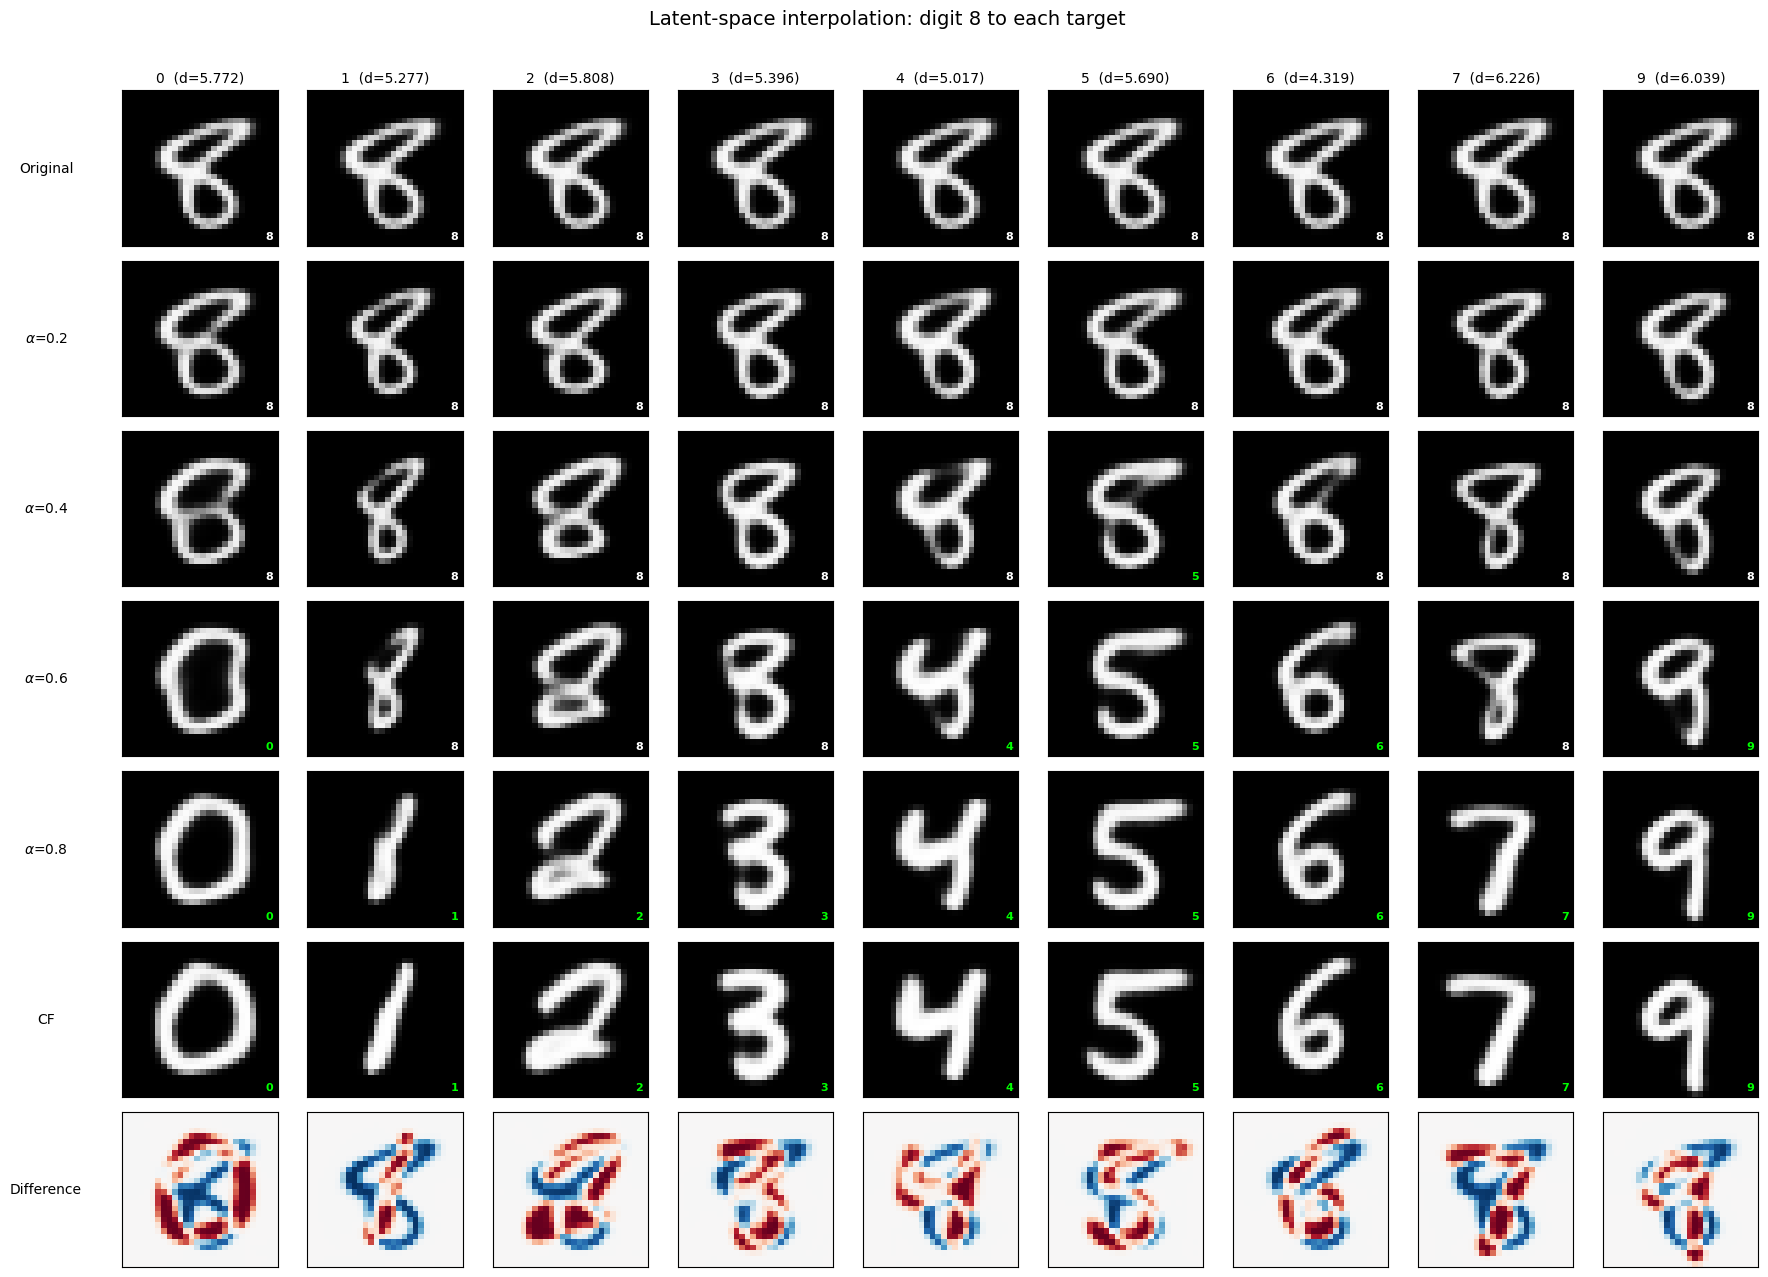

In [ ]:
query_idx = 1
z_orig = query_points[query_idx]

target_classes = sorted(all_results.keys())
n_targets = len(target_classes)

# Interpolation steps
alphas = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
n_steps = len(alphas)
n_rows = n_steps + 1  # +1 for difference map

fig, axes = plt.subplots(n_rows, n_targets, figsize=(2 * n_targets, 1.8 * n_rows))

# Row labels
row_labels = [f'$\\alpha$={a:.1f}' for a in alphas] + ['Difference']
row_labels[0] = 'Original'
row_labels[-2] = 'CF'
for row, label in enumerate(row_labels):
    axes[row, 0].set_ylabel(label, fontsize=10, rotation=0, labelpad=55, va='center')

# Decode original for difference computation
img_orig = decode_to_image(z_orig)

for col, target_class in enumerate(target_classes):
    result = all_results[target_class][query_idx]

    if not result.success:
        axes[0, col].set_title(f'{target_class}\n(failed)', fontsize=10)
        for row in range(n_rows):
            axes[row, col].axis('off')
        continue

    z_cf = result.x_cf
    axes[0, col].set_title(f'{target_class}  (d={result.distance:.3f})', fontsize=10)

    # Interpolation rows
    for row, alpha in enumerate(alphas):
        ax = axes[row, col]
        z_interp = (1 - alpha) * z_orig + alpha * z_cf
        img_interp = decode_to_image(z_interp)
        ax.imshow(img_interp, cmap='gray', vmin=0, vmax=1)
        ax.set_xticks([])
        ax.set_yticks([])

        # Show model prediction (via composite model)
        with torch.no_grad():
            z_t = torch.tensor(z_interp, dtype=torch.float32).unsqueeze(0).to(device)
            pred = composite_model(z_t).argmax(dim=1).item()
        color = 'lime' if pred == target_class else ('white' if pred == source_class else 'orange')
        ax.text(0.97, 0.03, str(pred), fontsize=8, color=color, fontweight='bold',
                ha='right', va='bottom', transform=ax.transAxes,
                bbox=dict(boxstyle='round,pad=0.15', fc='black', alpha=0.7))

    # Difference row (in image space)
    img_cf = decode_to_image(z_cf)
    diff = img_cf - img_orig
    vmax = max(abs(diff.min()), abs(diff.max()))
    ax = axes[-1, col]
    if vmax > 0:
        ax.imshow(diff, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    else:
        ax.imshow(diff, cmap='RdBu_r')
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle(f'Latent-space interpolation: digit {source_class} to each target', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 8 – δ-Robust Counterfactuals in Latent Space

Same δ-robustness mechanism, but now applied in the 3D latent space. The erosion guarantees that the entire ball $\mathcal{B}_q(\mathbf{z}_{cf}, \delta)$ in latent space lies inside the certified polytope.

In [ ]:
z_query = atlas.bounds[3]['X'][0]
target = 8

print(f'Query: digit 3, target: digit {target}')
print(f'Atlas norm: L{atlas.norm}, eps={atlas.eps}')
print(f'Latent dim: {len(z_query)}\n')

delta_values = [0.0, 0.001, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2]

print(f'--- Robustness norm = L{atlas.norm} (same as atlas) ---')
for delta in delta_values:
    result = atlas.find_counterfactual(z_query, target, method='bvh', delta=delta)
    if result.success:
        v = atlas.verify_counterfactual(result.x_cf, target)
        print(f'  delta={delta:.3f}: latent_dist={result.distance:.4f}, QPs={result.n_qp_solved}, valid={v["valid"]}')
    else:
        print(f'  delta={delta:.3f}: FAILED (eroded polytope empty)')

print()
print('--- Robustness norm = L∞ (cross-norm) ---')
for delta in delta_values:
    result = atlas.find_counterfactual(z_query, target, method='bvh',
                                       delta=delta, robust_norm=np.inf)
    if result.success:
        v = atlas.verify_counterfactual(result.x_cf, target)
        print(f'  delta={delta:.3f}: latent_dist={result.distance:.4f}, QPs={result.n_qp_solved}, valid={v["valid"]}')
    else:
        print(f'  delta={delta:.3f}: FAILED (eroded polytope empty)')

Query: digit 3, target: digit 8
Atlas norm: L1, eps=0.1
Latent dim: 32

--- Robustness norm = L1 (same as atlas) ---
  delta=0.000: latent_dist=5.5468, QPs=52, valid=True
  delta=0.001: latent_dist=5.5473, QPs=52, valid=True
  delta=0.005: latent_dist=5.5493, QPs=52, valid=True
  delta=0.010: latent_dist=5.5518, QPs=52, valid=True
  delta=0.020: latent_dist=5.5569, QPs=52, valid=True
  delta=0.050: latent_dist=5.5721, QPs=52, valid=True
  delta=0.100: FAILED (eroded polytope empty)
  delta=0.200: FAILED (eroded polytope empty)

--- Robustness norm = L∞ (cross-norm) ---
  delta=0.000: latent_dist=5.5468, QPs=52, valid=True
  delta=0.001: latent_dist=5.5630, QPs=52, valid=True
  delta=0.005: FAILED (eroded polytope empty)
  delta=0.010: FAILED (eroded polytope empty)
  delta=0.020: FAILED (eroded polytope empty)
  delta=0.050: FAILED (eroded polytope empty)
  delta=0.100: FAILED (eroded polytope empty)
  delta=0.200: FAILED (eroded polytope empty)


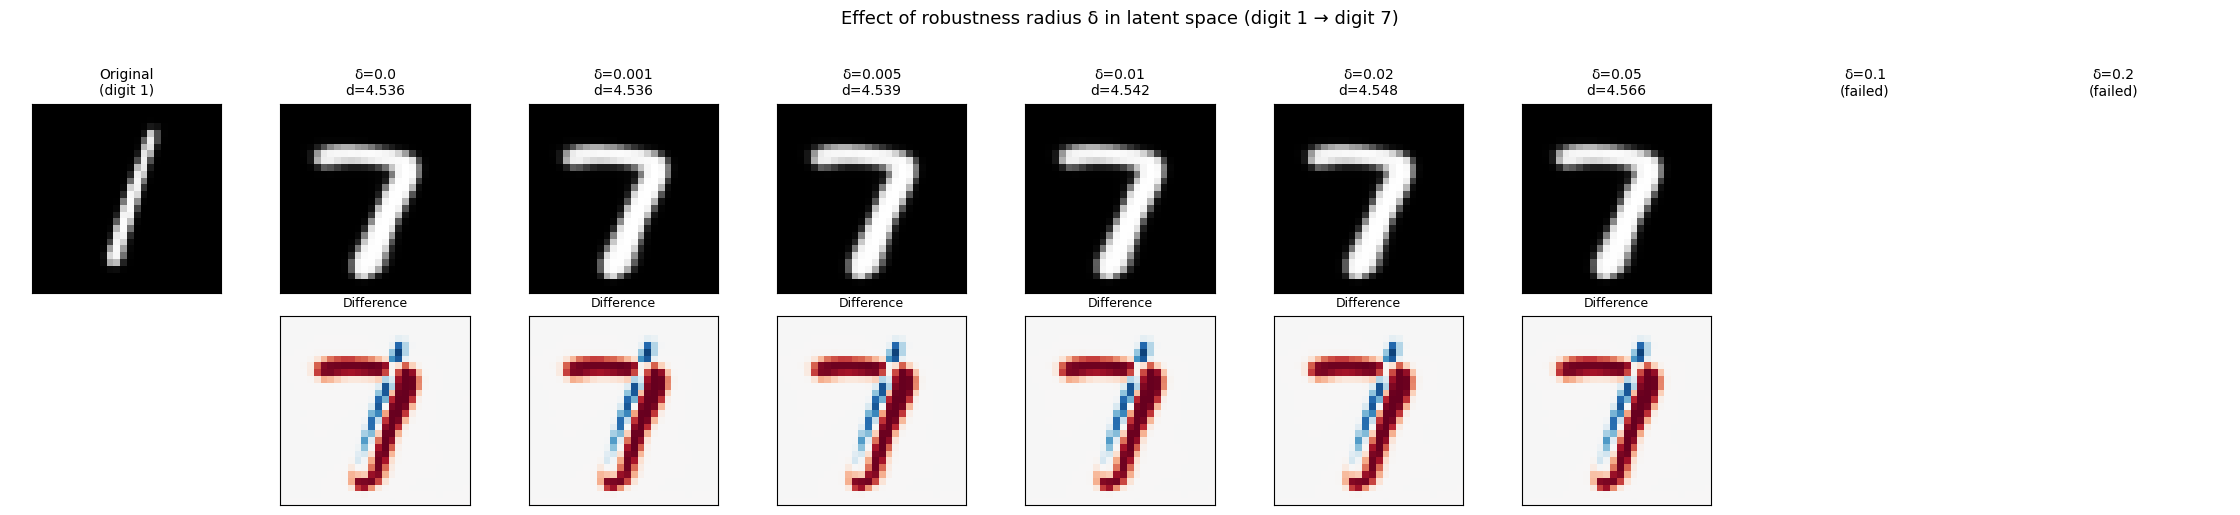

In [ ]:
# Visualize the effect of increasing delta on a counterfactual (decoded to image space)
z_query_vis = atlas.bounds[1]['X'][0]
target = 7

fig, axes = plt.subplots(2, len(delta_values) + 1, figsize=(2.5 * (len(delta_values) + 1), 5))

# Show original (decoded)
axes[0, 0].imshow(decode_to_image(z_query_vis), cmap='gray', vmin=0, vmax=1)
axes[0, 0].set_title(f'Original\n(digit 1)', fontsize=10)
axes[1, 0].axis('off')
for row in range(2):
    axes[row, 0].set_xticks([])
    axes[row, 0].set_yticks([])

img_orig_vis = decode_to_image(z_query_vis)

for col, delta in enumerate(delta_values, 1):
    result = atlas.find_counterfactual(z_query_vis, target, method='bvh', delta=delta)
    for row in range(2):
        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])

    if result.success:
        img_cf = decode_to_image(result.x_cf)
        axes[0, col].imshow(img_cf, cmap='gray', vmin=0, vmax=1)
        axes[0, col].set_title(f'δ={delta}\nd={result.distance:.3f}', fontsize=10)

        diff = img_cf - img_orig_vis
        vmax = max(abs(diff.min()), abs(diff.max()))
        if vmax > 0:
            axes[1, col].imshow(diff, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
        else:
            axes[1, col].imshow(diff, cmap='RdBu_r')
        axes[1, col].set_title('Difference', fontsize=9)
    else:
        axes[0, col].set_title(f'δ={delta}\n(failed)', fontsize=10)
        axes[0, col].axis('off')
        axes[1, col].axis('off')

fig.suptitle(f'Effect of robustness radius δ in latent space (digit 1 → digit {target})', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 9 – Benchmark: BVH vs k-NN Search (Latent Space)

In 3D latent space, each QP solve is much cheaper than in 784D. Let's see how BVH pruning compares.

In [ ]:
import time

n_test = 5
test_queries = atlas.bounds[0]['X'][:n_test]
target = 9
n_polytopes = len(atlas.bounds[target]['X'])

print(f'Benchmarking {n_test} queries (digit 0 -> digit {target})')
print(f'Total polytopes in target class: {n_polytopes}')
print('=' * 60)

bvh_qps, knn_qps = [], []
bvh_times, knn_times = [], []

for i, x0 in enumerate(test_queries):
    # BVH
    t0 = time.time()
    result_bvh = atlas.find_counterfactual(x0, target, method='bvh')
    t_bvh = time.time() - t0

    # k-NN (k = all polytopes)
    t0 = time.time()
    result_knn = atlas.find_counterfactual(x0, target, method='knn', k=n_polytopes)
    t_knn = time.time() - t0

    bvh_qps.append(result_bvh.n_qp_solved)
    knn_qps.append(result_knn.n_qp_solved)
    bvh_times.append(t_bvh)
    knn_times.append(t_knn)

    match = np.isclose(result_bvh.distance, result_knn.distance, atol=1e-3)
    print(f'Query {i}: BVH {result_bvh.n_qp_solved:3d} QPs ({t_bvh:5.1f}s) | '
          f'k-NN {result_knn.n_qp_solved:3d} QPs ({t_knn:5.1f}s) | '
          f'dist={result_bvh.distance:.2f} {"✓" if match else "✗"}')

print('=' * 60)
print(f'Avg QPs:  BVH = {np.mean(bvh_qps):.1f},  k-NN = {np.mean(knn_qps):.1f}  '
      f'({np.mean(knn_qps)/np.mean(bvh_qps):.1f}x fewer with BVH)')
print(f'Avg time: BVH = {np.mean(bvh_times):.1f}s,  k-NN = {np.mean(knn_times):.1f}s  '
      f'({np.mean(knn_times)/np.mean(bvh_times):.1f}x speedup with BVH)')

Benchmarking 5 queries (digit 0 -> digit 9)
Total polytopes in target class: 100
Query 0: BVH  96 QPs (  0.3s) | k-NN 100 QPs (  0.3s) | dist=5.57 ✓
Query 1: BVH  98 QPs (  0.3s) | k-NN 100 QPs (  0.3s) | dist=6.33 ✓
Query 2: BVH  92 QPs (  0.3s) | k-NN 100 QPs (  0.3s) | dist=4.93 ✓
Query 3: BVH  96 QPs (  0.3s) | k-NN 100 QPs (  0.3s) | dist=7.08 ✓
Query 4: BVH  96 QPs (  0.3s) | k-NN 100 QPs (  0.3s) | dist=6.16 ✓
Avg QPs:  BVH = 95.6,  k-NN = 100.0  (1.0x fewer with BVH)
Avg time: BVH = 0.3s,  k-NN = 0.3s  (1.0x speedup with BVH)


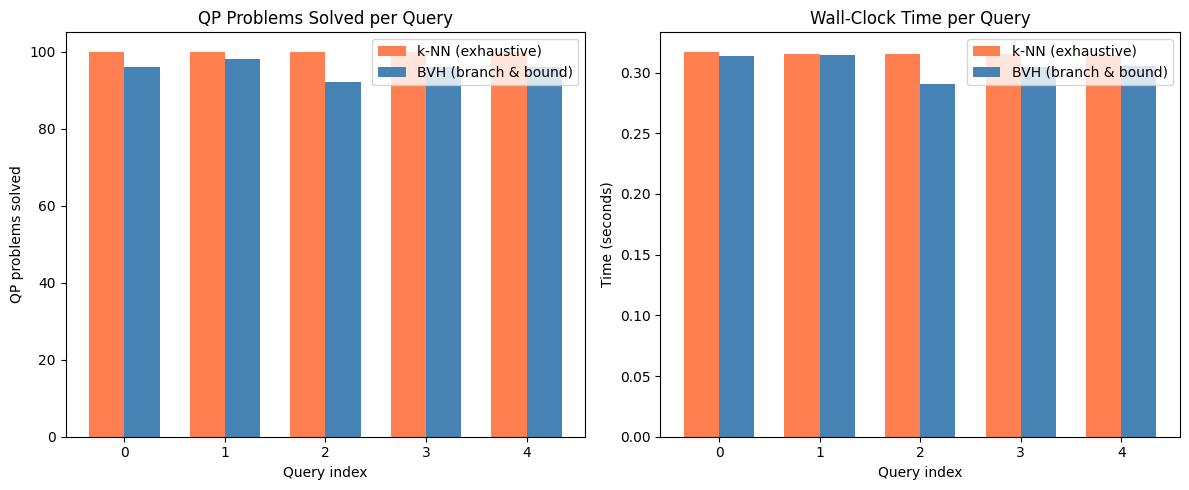

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# QPs comparison
ax = axes[0]
x_pos = np.arange(n_test)
width = 0.35
ax.bar(x_pos - width/2, knn_qps, width, label='k-NN (exhaustive)', color='coral')
ax.bar(x_pos + width/2, bvh_qps, width, label='BVH (branch & bound)', color='steelblue')
ax.set_xlabel('Query index')
ax.set_ylabel('QP problems solved')
ax.set_title('QP Problems Solved per Query')
ax.legend()

# Time comparison
ax = axes[1]
ax.bar(x_pos - width/2, knn_times, width, label='k-NN (exhaustive)', color='coral')
ax.bar(x_pos + width/2, bvh_times, width, label='BVH (branch & bound)', color='steelblue')
ax.set_xlabel('Query index')
ax.set_ylabel('Time (seconds)')
ax.set_title('Wall-Clock Time per Query')
ax.legend()

plt.tight_layout()
plt.show()

## 10 – Counterfactual Quality Metrics

We compute metrics both in **latent space** (where the atlas operates) and in **image space** (decoded).

In [ ]:
from sklearn.neighbors import LocalOutlierFactor
import pandas as pd

# Generate counterfactuals for several source/target pairs and compute metrics
source_digits = [0, 1, 3, 7]
n_queries_per = 5

rows = []
for source_class in source_digits:
    queries = atlas.bounds[source_class]['X'][:n_queries_per]

    for target_class in range(10):
        if target_class == source_class:
            continue

        # LOF in latent space
        target_data = atlas.bounds[target_class]['X']
        n_neighbors = min(10, len(target_data) - 1)
        lof = LocalOutlierFactor(n_neighbors=n_neighbors, novelty=True)
        lof.fit(target_data)

        for i, z_q in enumerate(queries):
            result = atlas.find_counterfactual(z_q, target_class, method='bvh')
            if not result.success:
                continue

            z_cf = result.x_cf
            z_diff = z_cf - z_q

            # Decode both to image space for pixel-level metrics
            img_orig = decode_to_image(z_q)
            img_cf = decode_to_image(z_cf)
            img_diff = img_cf - img_orig

            rows.append({
                'source': source_class,
                'target': target_class,
                'query_idx': i,
                # Latent space metrics
                'latent_l2_distance': np.linalg.norm(z_diff),
                'latent_linf_distance': np.max(np.abs(z_diff)),
                'lof_score': -lof.score_samples(z_cf.reshape(1, -1))[0],
                # Image space metrics (decoded)
                'image_l2_distance': np.linalg.norm(img_diff),
                'image_linf_distance': np.max(np.abs(img_diff)),
                'n_pixels_changed': int(np.sum(np.abs(img_diff) > 0.01)),
                'sparsity': np.sum(np.abs(img_diff) > 0.01) / 784,
                'n_qp_solved': result.n_qp_solved
            })

metrics_df = pd.DataFrame(rows)
print(f'Generated {len(metrics_df)} counterfactuals\n')
metrics_df.head(10)

Generated 180 counterfactuals



,source,target,query_idx,latent_l2_distance,latent_linf_distance,lof_score,image_l2_distance,image_linf_distance,n_pixels_changed,sparsity,n_qp_solved
0,0,1,0,4.773957,3.119792,1.109527,10.669895,0.997566,256,0.326531,7
1,0,1,1,4.995151,3.416746,1.059467,10.314284,0.988802,286,0.364796,35
2,0,1,2,4.946548,2.978226,1.059467,10.421357,0.990088,277,0.353316,53
3,0,1,3,6.274672,4.065802,1.301352,12.872568,0.998502,339,0.432398,10
4,0,1,4,5.074021,2.963272,1.231674,10.925202,0.997634,270,0.344388,13
5,0,2,0,4.809802,2.084632,1.080533,9.340070,0.981380,292,0.372449,14
6,0,2,1,4.740427,1.875432,1.076202,10.448707,0.993900,327,0.417092,55
7,0,2,2,5.367944,2.749034,1.076202,10.127709,0.995099,301,0.383929,67
8,0,2,3,5.073031,3.123806,1.080533,9.027453,0.995210,337,0.429847,8
9,0,2,4,5.146936,2.346886,1.124678,10.559200,0.997730,300,0.382653,50


INFO     19:21:51     [category.py:224] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO     19:21:51     [category.py:224] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO     19:21:51     [category.py:224] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO     19:21:51     [category.py:224] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO     19:21:51     [category.py:224] Using categorical units to plot a list o

/home/gabrielepintus/.local/lib/python3.13/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/home/gabrielepintus/.local/lib/python3.13/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/home/gabrielepintus/.local/lib/python3.13/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/home/gabrielepintus/.local/lib/python3.13/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


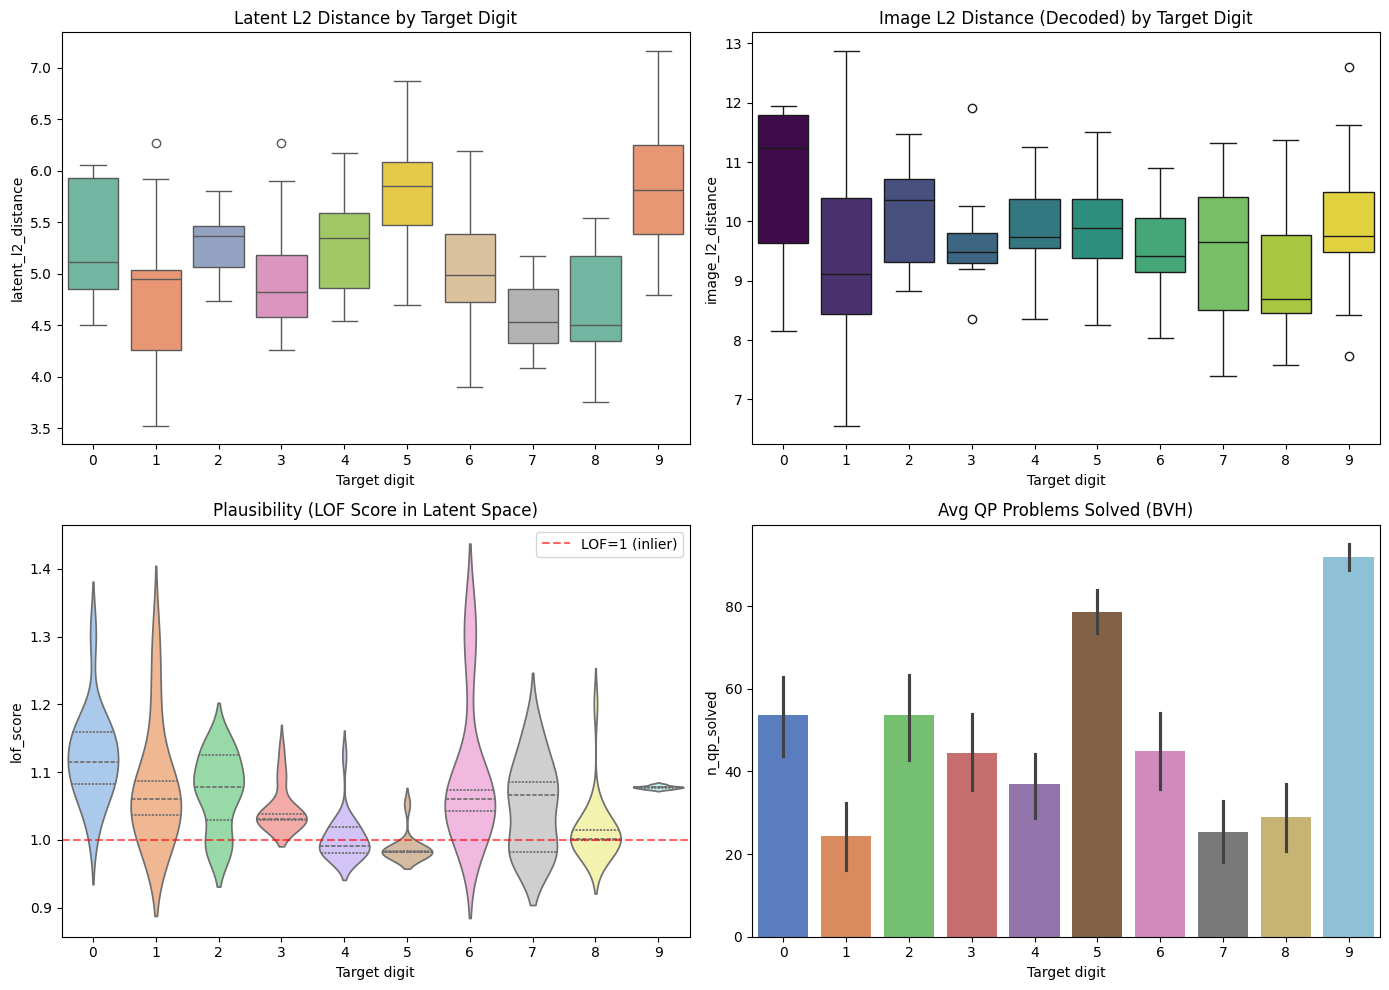

In [ ]:
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Latent L2 distance by target class
sns.boxplot(ax=axes[0, 0], x='target', y='latent_l2_distance', data=metrics_df,
            hue='target', palette='Set2', legend=False)
axes[0, 0].set_title('Latent L2 Distance by Target Digit')
axes[0, 0].set_xlabel('Target digit')

# Image L2 distance (decoded)
sns.boxplot(ax=axes[0, 1], x='target', y='image_l2_distance', data=metrics_df,
            hue='target', palette='viridis', legend=False)
axes[0, 1].set_title('Image L2 Distance (Decoded) by Target Digit')
axes[0, 1].set_xlabel('Target digit')

# LOF plausibility (in latent space)
sns.violinplot(ax=axes[1, 0], x='target', y='lof_score', data=metrics_df,
               hue='target', palette='pastel', legend=False, inner='quart')
axes[1, 0].axhline(1.0, color='red', linestyle='--', alpha=0.6, label='LOF=1 (inlier)')
axes[1, 0].set_title('Plausibility (LOF Score in Latent Space)')
axes[1, 0].set_xlabel('Target digit')
axes[1, 0].legend()

# QPs solved (efficiency)
sns.barplot(ax=axes[1, 1], x='target', y='n_qp_solved', data=metrics_df,
            hue='target', palette='muted', legend=False, estimator='mean')
axes[1, 1].set_title('Avg QP Problems Solved (BVH)')
axes[1, 1].set_xlabel('Target digit')

plt.tight_layout()
plt.show()

## Summary

We demonstrated certified counterfactual generation in the **latent space** of a convolutional VAE:

```python
# Composite model: decoder → classifier
composite_model = DecoderClassifier(autoencoder.decoder, classifier)

# Encode data to latent space (use mu for deterministic representation)
mu, logvar = autoencoder.encoder(images)
latent_dataset = TensorDataset(mu, labels)

# Build atlas in 3D latent space (offline)
atlas = CertCFAtlas(composite_model, latent_dataset, device, cnn=False)
atlas.build(eps=0.1, norm=1)

# Find counterfactual in latent space (online)
mu_query, _ = autoencoder.encoder(x_query)
result = atlas.find_counterfactual(mu_query, target_class=3)

# Decode back to image space
x_cf = autoencoder.decoder(result.x_cf)
```

Key observations:
- **3D vs 784D**: QP solves are dramatically faster in latent space
- **VAE regularization**: KL divergence encourages a structured latent space, potentially improving polytope quality
- **Manifold-constrained**: Decoded counterfactuals follow the VAE's learned image manifold
- **Certified validity**: All counterfactuals are guaranteed to be classified as the target digit (through the decoder→classifier pipeline)
- **Same δ-robustness**: Robustness guarantees transfer to latent space perturbations